Customer Compliant Classification


The dataset is from the Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database, which provides publicly available financial complaint records submitted by consumers.

https://www.consumerfinance.gov/data-research/consumer-complaints/

In [10]:
import json
import numpy as np
import pandas as pd
import re
import spacy
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from wordcloud import WordCloud


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can update the `data_path` to point to the location of your `complaints.json` file within your Drive. For example, if your file is in the root of your Drive, the path would be `/content/drive/MyDrive/complaints.json`.

In [12]:
data_path = "/content/drive/MyDrive/Colab Notebooks/NLP/complaints_as_json.json"

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import json
import pandas as pd

with open(data_path, "r") as file:
    raw_data = json.load(file)

df = pd.json_normalize(raw_data)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

tqdm.pandas()

# load spacy model
nlp_model = spacy.load("en_core_web_sm")

In [15]:
df.head()

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,_source.consumer_disputed,_source.product,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,N/A,Debt collection,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,N/A,Mortgage,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,N/A,Credit card or prepaid card,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78313 entries, 0 to 78312
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   _index                             78313 non-null  object 
 1   _type                              78313 non-null  object 
 2   _id                                78313 non-null  object 
 3   _score                             78313 non-null  float64
 4   _source.tags                       10900 non-null  object 
 5   _source.zip_code                   71556 non-null  object 
 6   _source.complaint_id               78313 non-null  object 
 7   _source.issue                      78313 non-null  object 
 8   _source.date_received              78313 non-null  object 
 9   _source.state                      76322 non-null  object 
 10  _source.consumer_disputed          78313 non-null  object 
 11  _source.product                    78313 non-null  obj

In [17]:
df.describe()

,_score
count,78313.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [18]:
df.describe(include="object").T

,count,unique,top,freq
_index,78313,1,complaint-public-v2,78313
_type,78313,1,complaint,78313
_id,78313,78313,2001189,1
_source.tags,10900,3,Older American,6103
_source.zip_code,71556,9442,606XX,472
_source.complaint_id,78313,78313,2001189,1
_source.issue,78313,154,"Loan modification,collection,foreclosure",9743
_source.date_received,78313,3444,2015-08-27T12:00:00-05:00,82
_source.state,76322,62,CA,14009
_source.consumer_disputed,78313,3,N/A,35683


In [19]:
df.columns

Index(['_index', '_type', '_id', '_score', '_source.tags', '_source.zip_code',
       '_source.complaint_id', '_source.issue', '_source.date_received',
       '_source.state', '_source.consumer_disputed', '_source.product',
       '_source.company_response', '_source.company', '_source.submitted_via',
       '_source.date_sent_to_company', '_source.company_public_response',
       '_source.sub_product', '_source.timely',
       '_source.complaint_what_happened', '_source.sub_issue',
       '_source.consumer_consent_provided'],
      dtype='object')

In [20]:
def clean_column_name(col):
    if col.startswith("_source."):
        return col.replace("_source.", "")
    elif col.startswith("_"):
        return col[1:]
    return col

df.columns = [clean_column_name(col) for col in df.columns]

In [21]:
df = df[df["complaint_what_happened"].replace("", np.nan).notnull()]

In [22]:
df = df.drop_duplicates(subset=["complaint_what_happened"])

Remove categories with fewer than 500 complaints
because small classes lack sufficient training data:


In [23]:
top_categories = df["product"].value_counts()
top_categories = top_categories[top_categories > 500].index
df = df[df["product"].isin(top_categories)]


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19997 entries, 1 to 78311
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      19997 non-null  object 
 1   type                       19997 non-null  object 
 2   id                         19997 non-null  object 
 3   score                      19997 non-null  float64
 4   tags                       3647 non-null   object 
 5   zip_code                   15630 non-null  object 
 6   complaint_id               19997 non-null  object 
 7   issue                      19997 non-null  object 
 8   date_received              19997 non-null  object 
 9   state                      19859 non-null  object 
 10  consumer_disputed          19997 non-null  object 
 11  product                    19997 non-null  object 
 12  company_response           19997 non-null  object 
 13  company                    19997 non-null  object 


In [25]:
df["product"].unique()

array(['Debt collection', 'Credit card or prepaid card',
       'Credit reporting, credit repair services, or other personal consumer reports',
       'Checking or savings account',
       'Money transfer, virtual currency, or money service', 'Mortgage',
       'Bank account or service', 'Credit card'], dtype=object)

In [26]:
def merge_products(p):
    if "Credit card" in p:
        return "Credit card"
    elif "account" in p:
        return "Bank account"
    else:
        return p

df["product_cleaned"] = df["product"].apply(merge_products)

In [27]:
df["date_received"] = pd.to_datetime(df["date_received"])

print("Min date:", df["date_received"].min())
print("Max date:", df["date_received"].max())

Min date: 2015-03-19 12:00:00-05:00
Max date: 2021-03-14 12:00:00-05:00


Group complaints by month to analyze trends over time
Plot number of complaints per month

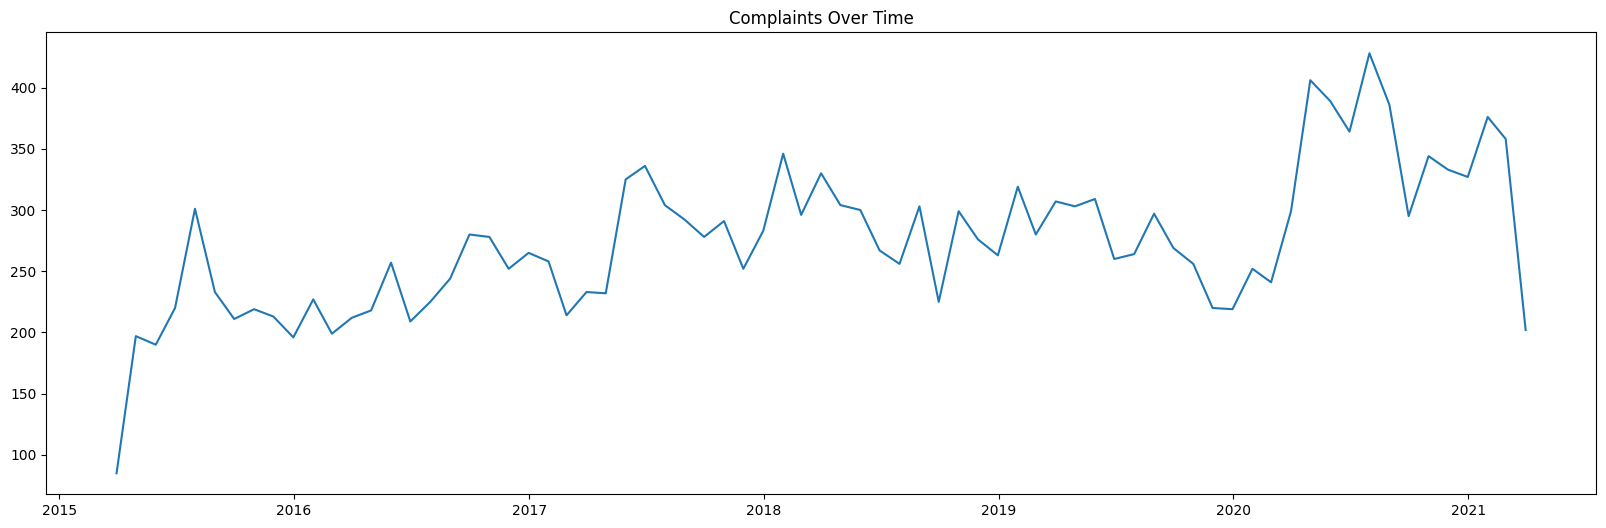

In [28]:
monthly_complaints = df.set_index("date_received").resample("M").size()

plt.figure(figsize=(20,6))
plt.plot(monthly_complaints.index, monthly_complaints)
plt.title("Complaints Over Time")
plt.show()

Count complaints per state
Visualize distribution of complaints across states

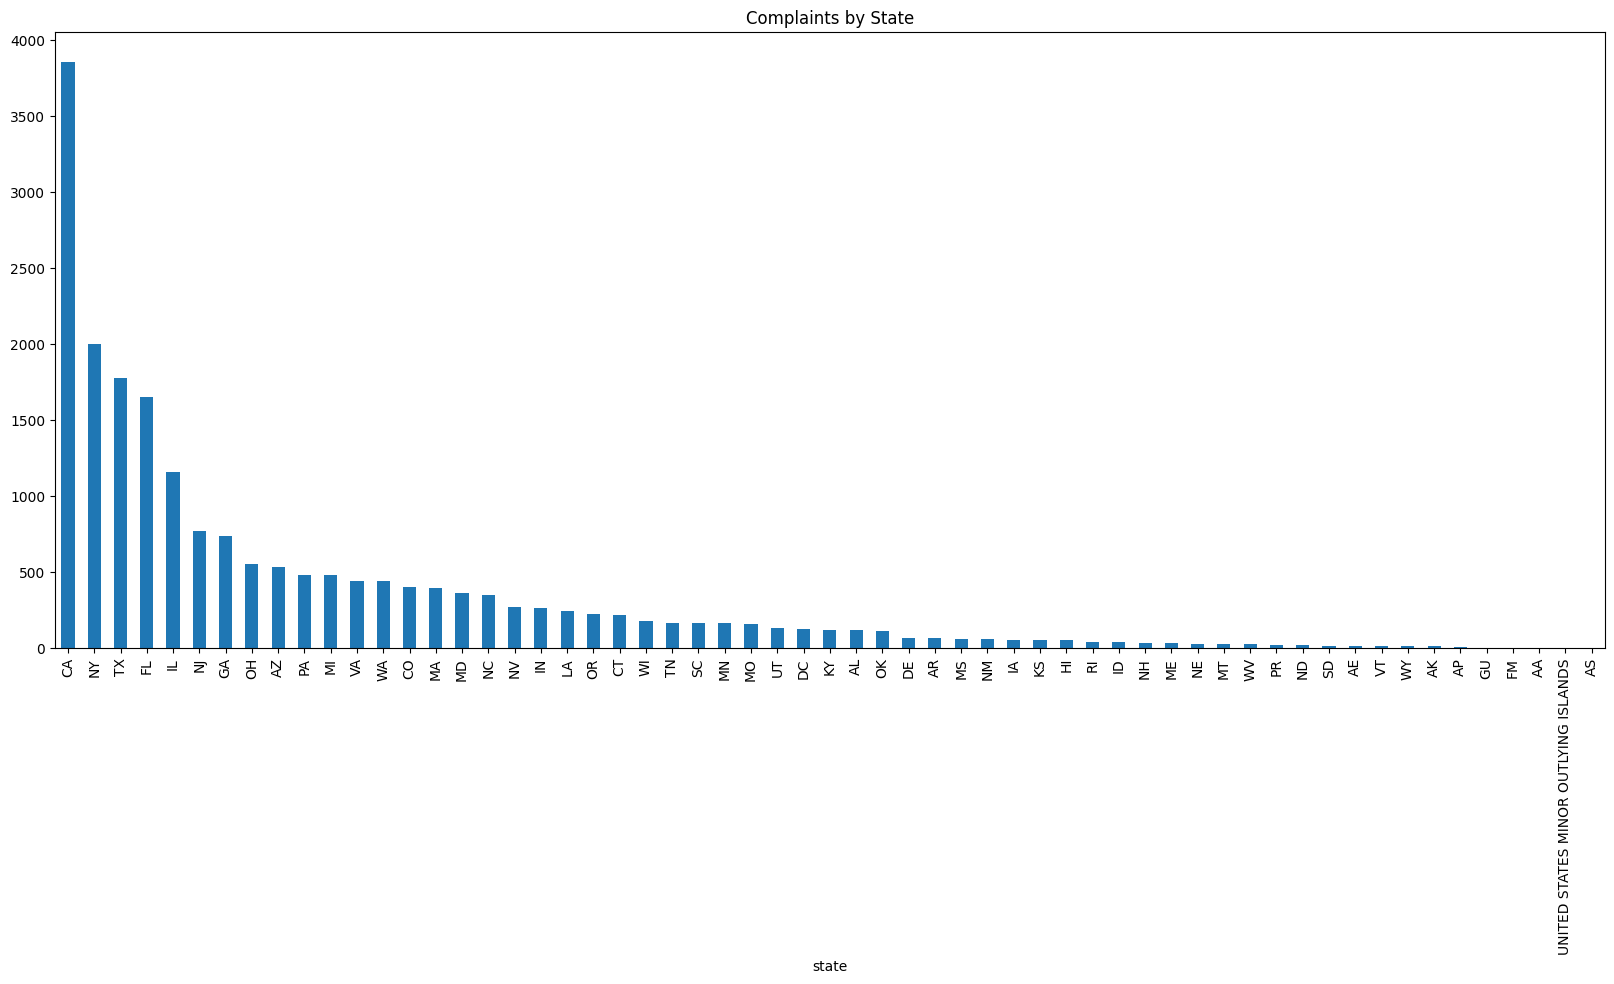

In [29]:
state_counts = df["state"].value_counts()

plt.figure(figsize=(20,8))
state_counts.plot(kind="bar")
plt.title("Complaints by State")
plt.show()

Count different complaint issues
Plot most common issues horizontally

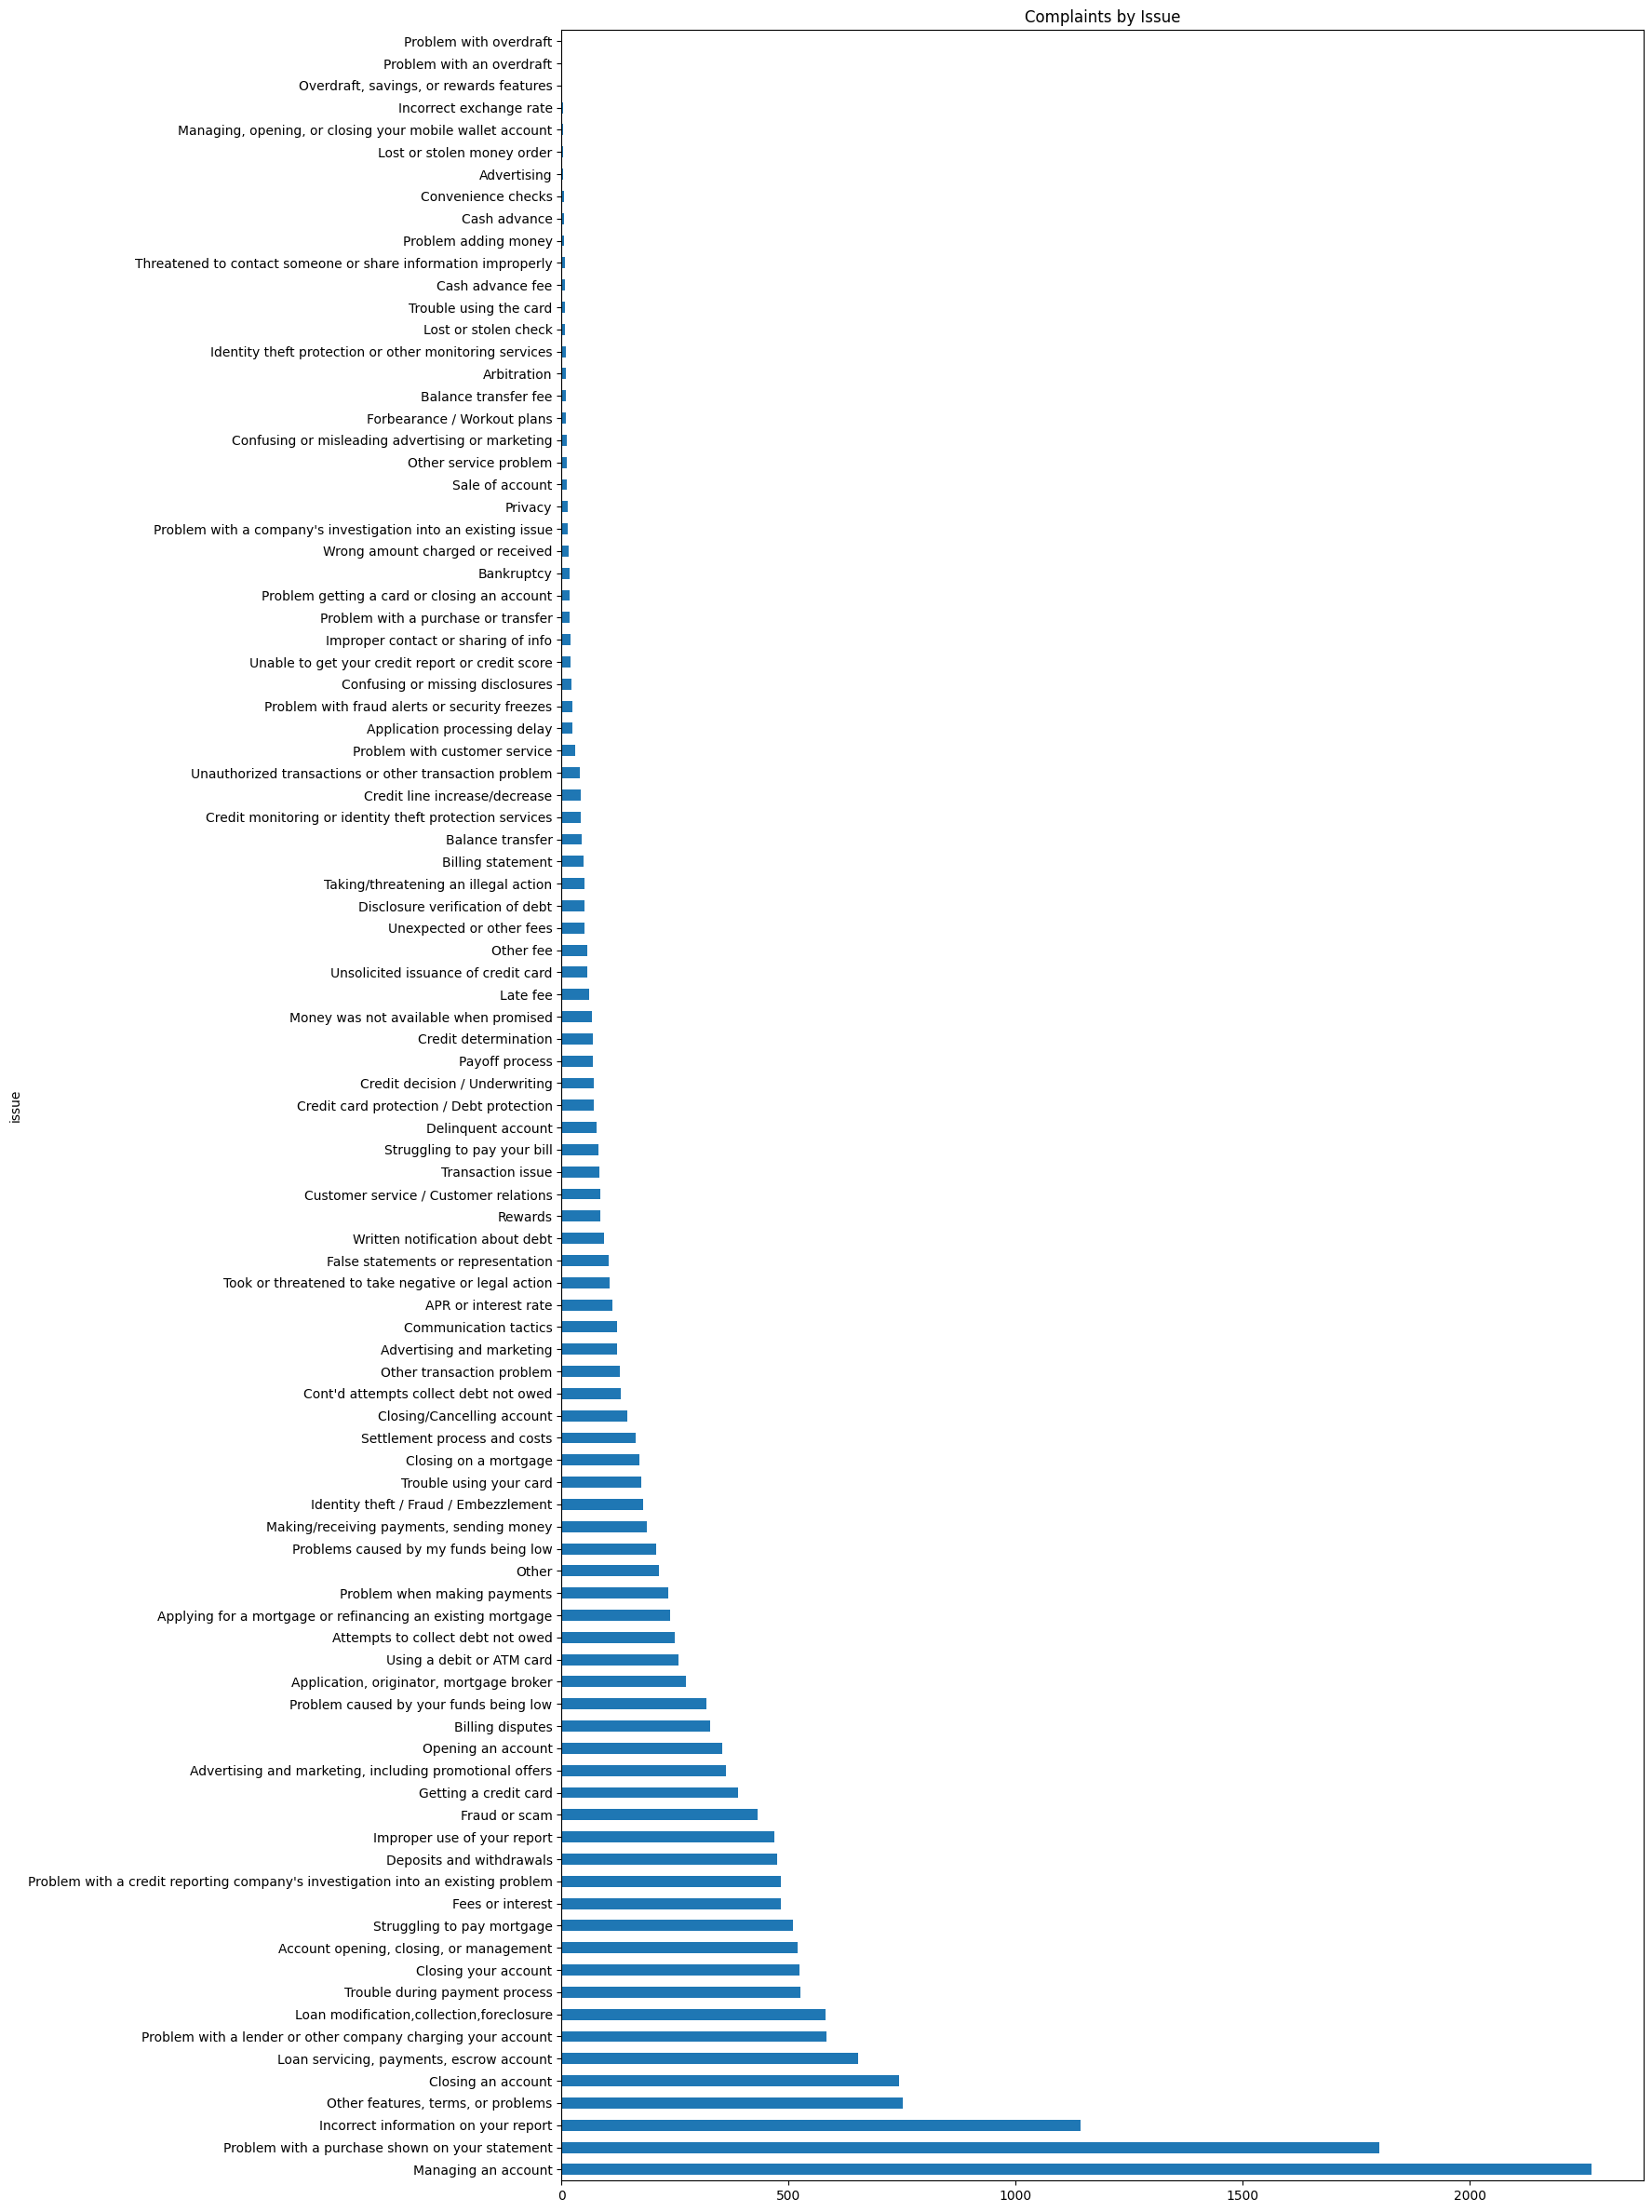

In [30]:
issue_counts = df["issue"].value_counts()

plt.figure(figsize=(15,30))
issue_counts.plot(kind="barh")
plt.title("Complaints by Issue")
plt.show()

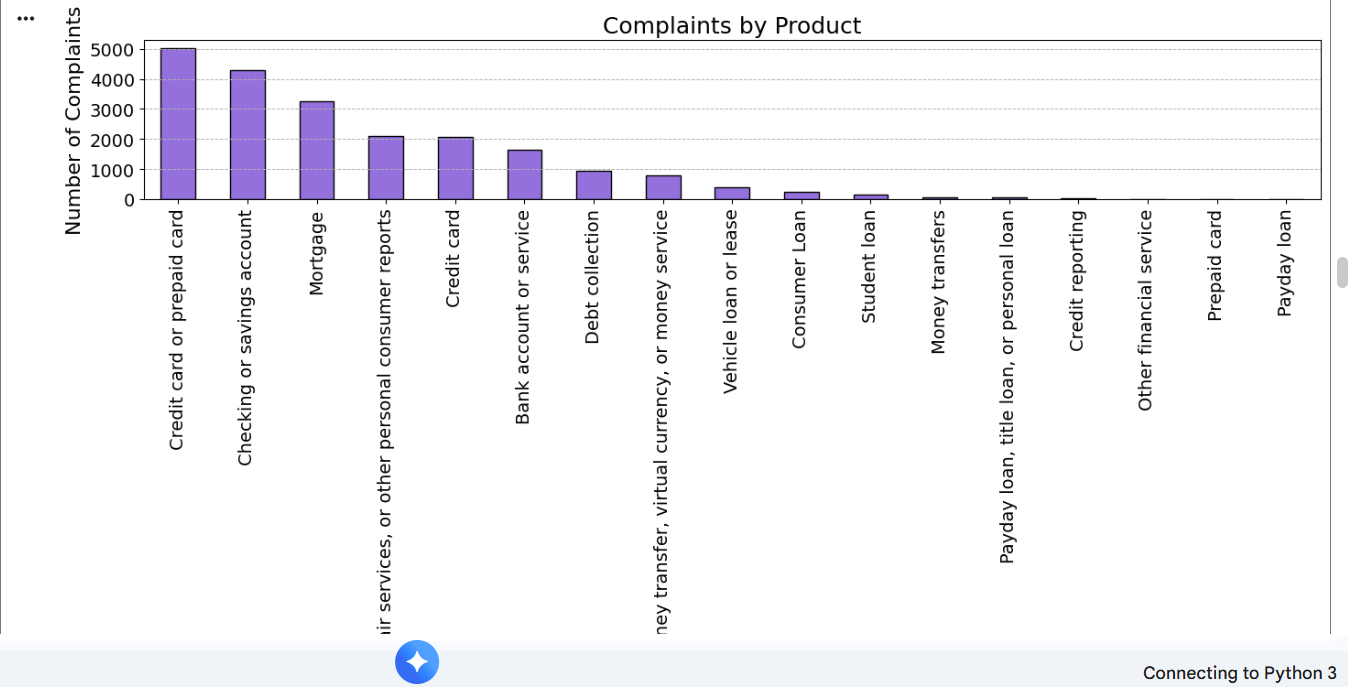

From the chart above, it is clear that some categories have very few complaints
(e.g., Payday loan, Prepaid card, Credit reporting have near-zero counts).
Therefore, we decided to remove categories with fewer than 500 complaints


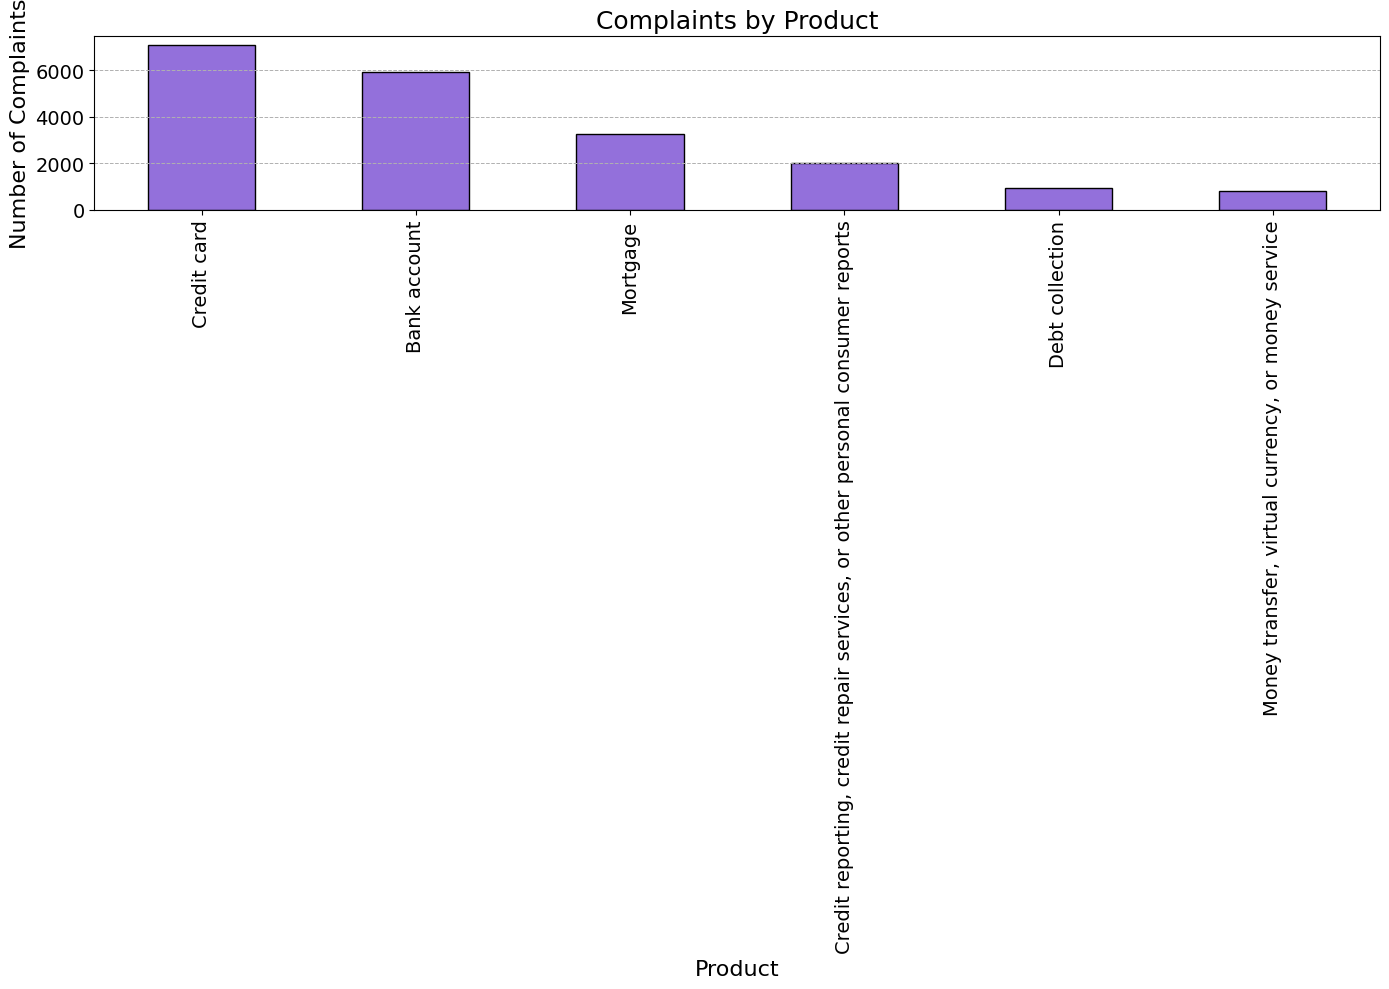

In [31]:
product_complaints = df['product_cleaned'].value_counts()

plt.figure(figsize=(14, 10))
product_complaints.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Complaints by Product', fontsize=18)
plt.xlabel('Product', fontsize=16)
plt.ylabel('Number of Complaints', fontsize=16)
plt.grid(axis='y', linestyle='--', linewidth=0.7)
plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\[.*?\]", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\w*\d\w*", " ", text)
    return text.strip()

In [33]:
df["clean_text"] = df["complaint_what_happened"].apply(clean_text)

In [34]:
def lemmatize_texts(texts):
    processed = []

    for doc in tqdm(nlp_model.pipe(texts)):
        tokens = [
            token.lemma_
            for token in doc
            if not token.is_stop and not token.is_punct
        ]
        processed.append(" ".join(tokens))

    return processed

df["lemmatized_text"] = lemmatize_texts(df["clean_text"])

19997it [09:08, 36.45it/s]


In [35]:
def extract_nouns(texts):
    nouns = []

    for doc in tqdm(nlp_model.pipe(texts)):
        nouns.append(" ".join([t.text for t in doc if t.pos_ == "NOUN"]))

    return nouns


df["noun_text"] = extract_nouns(df["lemmatized_text"])

19997it [04:34, 72.81it/s]


Analyze distribution of complaint lengths
Helps understand text size variation

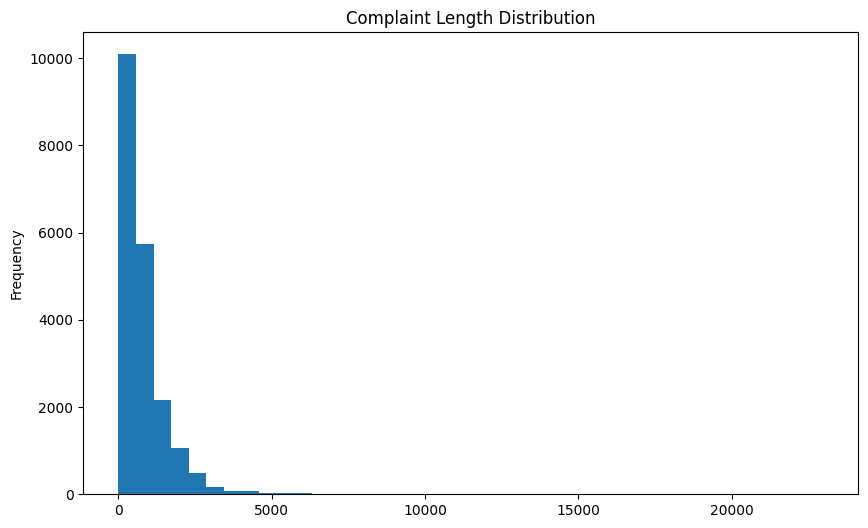

In [36]:
text_length = df["lemmatized_text"].str.len()

plt.figure(figsize=(10,6))
text_length.plot(kind="hist", bins=40)
plt.title("Complaint Length Distribution")
plt.show()

In [37]:
df_preprocessed = df[[
    "complaint_what_happened",
    "clean_text",
    "lemmatized_text",
    "noun_text",
    "product_cleaned"
]].copy()


In [38]:
df_preprocessed.head(2)

,complaint_what_happened,clean_text,lemmatized_text,noun_text,product_cleaned
1,Good morning my name is XXXX XXXX and I appreciate it if you could help me put a stop to Chase Bank cardmember services. \nIn 2018 I wrote to Chase asking for debt verification and what they sent me a statement which is not acceptable. I am asking the bank to validate the debt. Instead I been receiving mail every month from them attempting to collect a debt. \nI have a right to know this information as a consumer. \n\nChase account # XXXX XXXX XXXX XXXX Thanks in advance for your help.,good morning my name is xxxx xxxx and i appreciate it if you could help me put a stop to chase bank cardmember services \nin i wrote to chase asking for debt verification and what they sent me a statement which is not acceptable i am asking the bank to validate the debt instead i been receiving mail every month from them attempting to collect a debt \ni have a right to know this information as a consumer \n\nchase account xxxx xxxx xxxx xxxx thanks in advance for your help,good morning xxxx xxxx appreciate help stop chase bank cardmember service \n write chase ask debt verification send statement acceptable ask bank validate debt instead receive mail month attempt collect debt \n right know information consumer \n\n chase account xxxx xxxx xxxx xxxx thank advance help,morning help chase debt verification statement bank validate debt mail month attempt debt information consumer chase account advance help,Debt collection
2,I upgraded my XXXX XXXX card in XX/XX/2018 and was told by the agent who did the upgrade my anniversary date would not change. It turned the agent was giving me the wrong information in order to upgrade the account. XXXX changed my anniversary date from XX/XX/XXXX to XX/XX/XXXX without my consent! XXXX has the recording of the agent who was misled me.,i upgraded my xxxx xxxx card in xx xx and was told by the agent who did the upgrade my anniversary date would not change it turned the agent was giving me the wrong information in order to upgrade the account xxxx changed my anniversary date from xx xx xxxx to xx xx xxxx without my consent xxxx has the recording of the agent who was misled me,upgrade xxxx xxxx card xx xx tell agent upgrade anniversary date change turn agent give wrong information order upgrade account xxxx change anniversary date xx xx xxxx xx xx xxxx consent xxxx recording agent mislead,agent anniversary date change agent information order account change anniversary date agent mislead,Credit card


In [39]:
df_preprocessed.shape

(19997, 5)

In [40]:
df_preprocessed.isna().sum()

,0
complaint_what_happened,0
clean_text,0
lemmatized_text,0
noun_text,0
product_cleaned,0


In [41]:
df_preprocessed.columns

Index(['complaint_what_happened', 'clean_text', 'lemmatized_text', 'noun_text',
       'product_cleaned'],
      dtype='object')

In [42]:
df_preprocessed["complaint_cleaned"] = df_preprocessed["noun_text"].apply(
    lambda text: text.replace("-PRON-", "")
)

all_complaints = " ".join(df_preprocessed["complaint_cleaned"])

['credit card', 'chase', 'time', 'bank', 'day', 'state', 'request', 'information', 'year', 'issue', 'credit report', 'transaction', 'money', 'chase credit', 'month', 'contact', 't', 'work', 'company', 'account chase', 'customer service', 'chase bank', 'purchase', 'week', 'claim', 'call chase', 'payment', 'point', 'person', 'letter', 'chase account', 'reason', 'process', 'way', 'help', 'case', 'order', 'fact', 'today', 'date', 'attempt', 'document', 'pay', 'charge', 'situation', 'notice', 'account account', 'problem', 'contact chase', 'debit card']


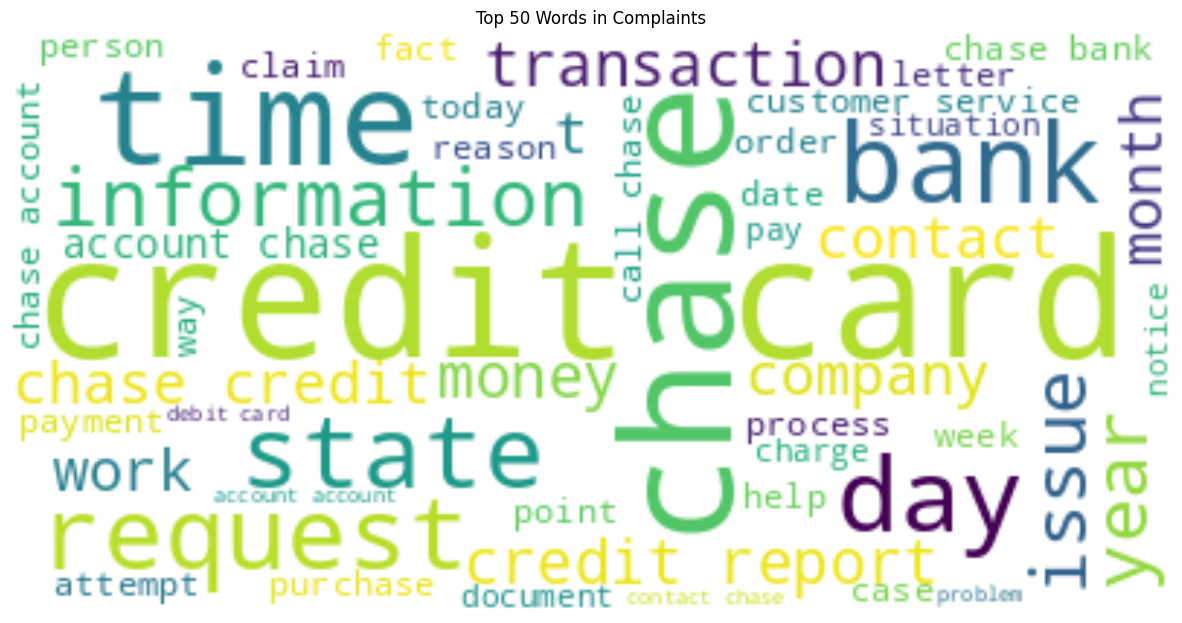

In [43]:
wordcloud = WordCloud(
    max_words=50,
    background_color="white",
    colormap="viridis"
).generate(all_complaints)

top_50_words = list(wordcloud.words_.keys())[:50]
print(top_50_words)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.title("Top 50 Words in Complaints")
plt.axis("off")
plt.show()

End of Engineer 1

In [ ]:
#Engneer 2

### Feature Engineering - TF-IDF Vectorization

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# max_features can be tuned to control the vocabulary size
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the lemmatized text
tfidf_features = tfidf_vectorizer.fit_transform(df_preprocessed["lemmatized_text"])

In [45]:
# Display the shape of the TF-IDF features matrix
print(f"Shape of TF-IDF features matrix: {tfidf_features.shape}")

Shape of TF-IDF features matrix: (19997, 5000)


This matrix (`tfidf_features`) now contains the TF-IDF scores for each word in each complaint, which can be used as input for a classification model. Next, we can consider splitting the data into training and testing sets.

### Splitting Data into Training and Testing Sets

In [46]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = tfidf_features
y = df_preprocessed["product_cleaned"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (15997, 5000)
Shape of X_test: (4000, 5000)
Shape of y_train: (15997,)
Shape of y_test: (4000,)


The data is now split into training and testing sets, with the TF-IDF features as `X` and the `product_cleaned` as the target `y`. The `stratify=y` argument ensures that the proportion of each product category is approximately the same in both training and testing sets, which is crucial for imbalanced datasets.

## Model Training

We will start with a simple yet effective model for text classification: Logistic Regression. This will serve as our baseline model.

In [47]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
# Set solver and max_iter for convergence; these can be tuned
logistic_model = LogisticRegression(solver='liblinear', max_iter=200, random_state=42)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Now that the model is trained, let's evaluate its performance on the test set using various metrics such as accuracy, precision, recall, and F1-score.

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8200

Classification Report:
                                                                              precision    recall  f1-score   support

                                                                Bank account       0.82      0.88      0.85      1187
                                                                 Credit card       0.81      0.89      0.85      1419
Credit reporting, credit repair services, or other personal consumer reports       0.74      0.61      0.67       400
                                                             Debt collection       0.73      0.40      0.52       186
                          Money transfer, virtual currency, or money service       0.75      0.39      0.51       159
                                                                    Mortgage       0.90      0.91      0.90       649

                                                                    accuracy                           0.82      4000
             

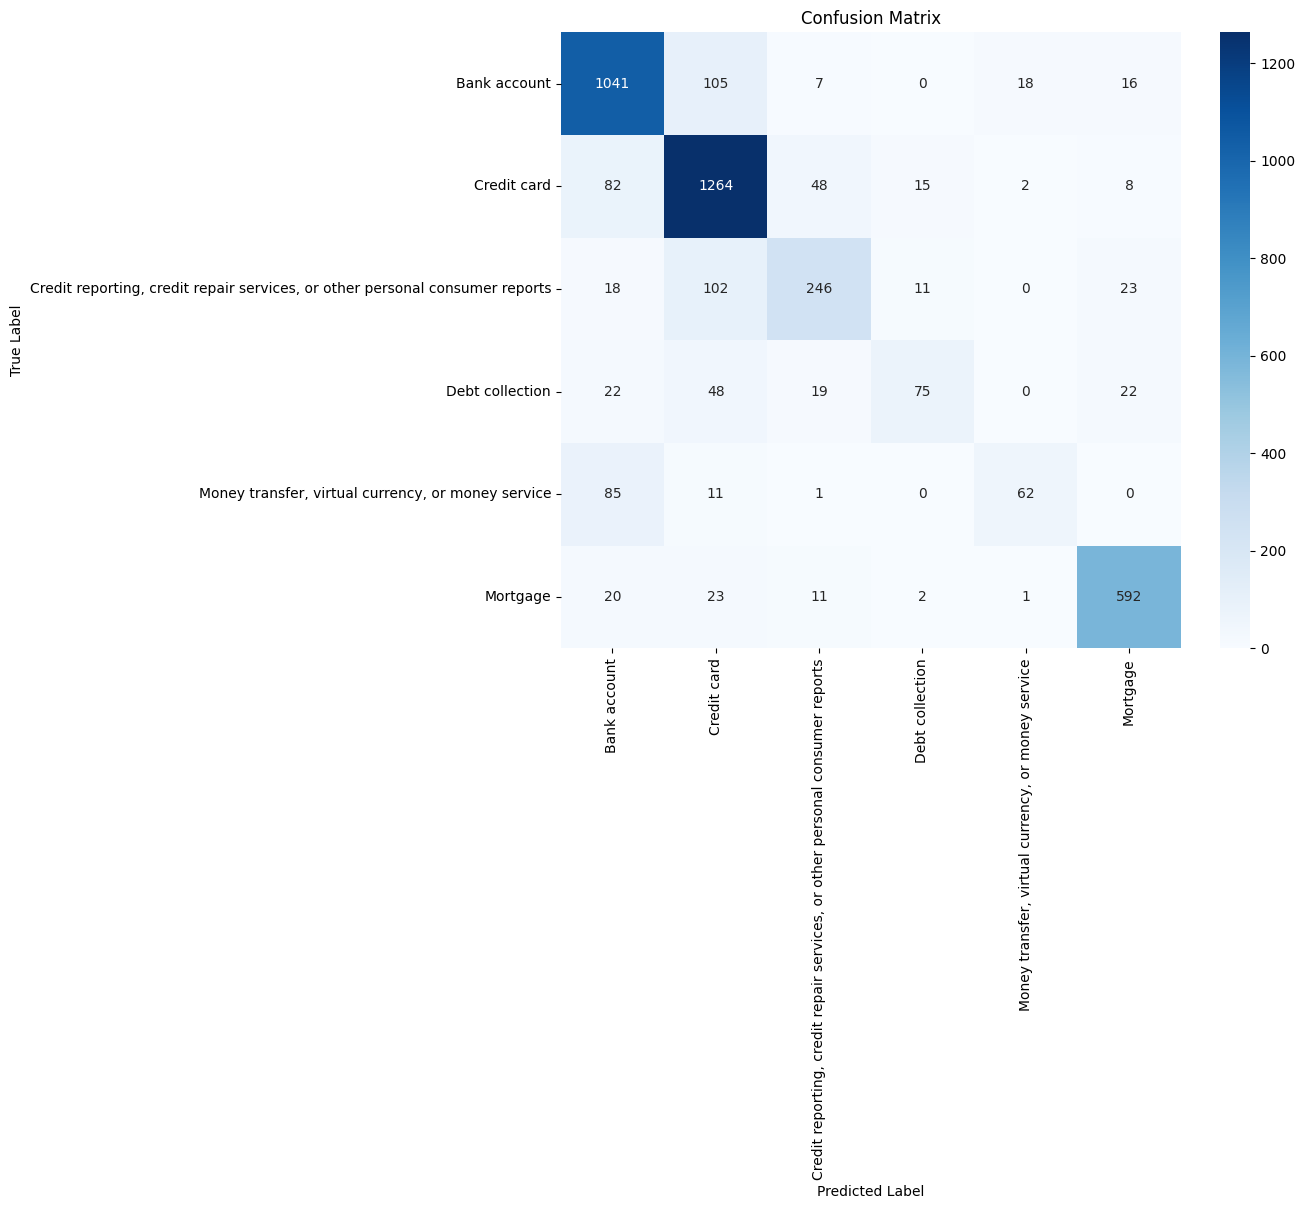

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_model.classes_, yticklabels=logistic_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix provides a visual representation of the model's performance, showing the number of correct and incorrect predictions for each product category. The classification report offers a more detailed breakdown of precision, recall, and F1-score for each class, which are crucial metrics for evaluating multi-class classification models, especially with potentially imbalanced classes.

### Feature Engineering - Dimensionality Reduction (TruncatedSVD/LSA)

In [50]:
from sklearn.decomposition import TruncatedSVD

# Initialize TruncatedSVD with 300 components
# The number of components can be tuned
lsa_model = TruncatedSVD(n_components=300, random_state=42)

# Fit and transform the TF-IDF features
lsa_features = lsa_model.fit_transform(tfidf_features)

print("TF-IDF features transformed using TruncatedSVD.")

TF-IDF features transformed using TruncatedSVD.


In [51]:
# Display the shape of the LSA features matrix
print(f"Shape of LSA features matrix: {lsa_features.shape}")

Shape of LSA features matrix: (19997, 300)


We have successfully reduced the dimensionality of our feature space from 5000 to 300 components using TruncatedSVD. These `lsa_features` can now be used as input for our machine learning model. This reduction can help in capturing underlying semantic structures in the text while making the model more efficient and potentially more robust.

### Splitting Data for LSA Features

In [52]:
from sklearn.model_selection import train_test_split

# Define features (X) as lsa_features and target (y) as product_cleaned
X_lsa = lsa_features
y_lsa = df_preprocessed["product_cleaned"]

# Split the data into training and testing sets
X_train_lsa, X_test_lsa, y_train_lsa, y_test_lsa = train_test_split(
    X_lsa, y_lsa, test_size=0.2, random_state=42, stratify=y_lsa
)

print(f"Shape of X_train_lsa: {X_train_lsa.shape}")
print(f"Shape of X_test_lsa: {X_test_lsa.shape}")
print(f"Shape of y_train_lsa: {y_train_lsa.shape}")
print(f"Shape of y_test_lsa: {y_test_lsa.shape}")

Shape of X_train_lsa: (15997, 300)
Shape of X_test_lsa: (4000, 300)
Shape of y_train_lsa: (15997,)
Shape of y_test_lsa: (4000,)


### Model Training with LSA Features (Logistic Regression)

In [53]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
logistic_model_lsa = LogisticRegression(solver='liblinear', max_iter=200, random_state=42)

# Train the model with LSA features
logistic_model_lsa.fit(X_train_lsa, y_train_lsa)

print("Logistic Regression model trained successfully with LSA features.")

Logistic Regression model trained successfully with LSA features.


### Model Evaluation with LSA Features

In [54]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set with LSA features
y_pred_lsa = logistic_model_lsa.predict(X_test_lsa)

# Evaluate the model
accuracy_lsa = accuracy_score(y_test_lsa, y_pred_lsa)
print(f"Accuracy with LSA features: {accuracy_lsa:.4f}")

print("\nClassification Report with LSA features:")
print(classification_report(y_test_lsa, y_pred_lsa))

Accuracy with LSA features: 0.8130

Classification Report with LSA features:
                                                                              precision    recall  f1-score   support

                                                                Bank account       0.82      0.87      0.84      1187
                                                                 Credit card       0.80      0.89      0.84      1419
Credit reporting, credit repair services, or other personal consumer reports       0.74      0.60      0.66       400
                                                             Debt collection       0.70      0.38      0.49       186
                          Money transfer, virtual currency, or money service       0.75      0.38      0.50       159
                                                                    Mortgage       0.88      0.91      0.90       649

                                                                    accuracy                   